## 1. Data loading and first look

Dataset: Stroke Prediction Dataset (https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset) (5110 patients, 12 features)

Goal: Identify clinical patterns that distinguish patients with and without stroke

Author: Nasir Nesirli

Tools: Python, Pandas, Matplotlib, Seaborn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

from stroke_risk_api.data.loaders import load_stroke_data

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [2]:
X, y = load_stroke_data()
df = pd.concat([X, y], axis=1)

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Shape: (5110, 12)
Columns: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


In [3]:
# Head of the df
df.head().T

,0,1,2,3,4
id,9046,51676,31112,60182,1665
gender,Male,Female,Male,Female,Female
age,67.0,61.0,80.0,49.0,79.0
hypertension,0,0,0,0,1
heart_disease,1,0,1,0,0
ever_married,Yes,Yes,Yes,Yes,Yes
work_type,Private,Self-employed,Private,Private,Self-employed
Residence_type,Urban,Rural,Rural,Urban,Rural
avg_glucose_level,228.69,202.21,105.92,171.23,174.12
bmi,36.6,NaN,32.5,34.4,24.0


## 2. Data quality assessment

In [4]:
# Dtypes
print("Dtypes: ")
print(df.dtypes)

# Missing values
print("Missing values: ")
print(df.isnull().sum())

# Duplicate rows
print("Duplicate rows: ")
print(df.duplicated().sum())

Dtypes: 
id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object
Missing values: 
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64
Duplicate rows: 
0


In [5]:
# Where exactly are the missing values?
missing = df.isnull().sum()
missing_pct = ((missing / len(df)) * 100).round(2)

missing_df = pd.DataFrame({"count": missing, "pct": missing_pct}).query('count > 0')
print(missing_df)

     count   pct
bmi    201  3.93


### Renaming columns

In [6]:
df.columns = df.columns.str.lower().str.strip()

### Handling missing values

In [7]:
# Numeric — median imputation
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

# Verify
print(f"Missing values remaining: {df.isnull().sum().sum()}")
print(f"Shape unchanged: {df.shape}")

Missing values remaining: 0
Shape unchanged: (5110, 12)


## 3. Univariate analysis

### 3.1 Target variable - Stroke prevalence

In [8]:
target_counts = df["stroke"].value_counts()
target_pct = df["stroke"].value_counts(normalize=True)

print(target_counts)
print(f"Stroke: {target_pct[1] * 100:.2f}%")
print(f"No stroke: {target_pct[0] * 100:.2f}%")

stroke
0    4861
1     249
Name: count, dtype: int64
Stroke: 4.87%
No stroke: 95.13%


Targets are heavily imbalanced. Consider during modelling.

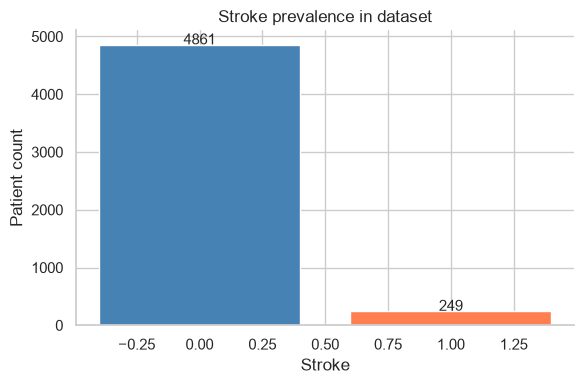

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(target_counts.index, target_counts.values, color=["steelblue", "coral"], edgecolor="white")
ax.set_title('Stroke prevalence in dataset')
ax.set_ylabel('Patient count')
ax.set_xlabel('Stroke')

for i, v in enumerate(target_counts.values):
    ax.text(i, v+2, str(v), ha="center", fontsize=11)

plt.tight_layout()
plt.show()

### 3.2 Numeric feature distributions

In [10]:
df.select_dtypes(include=['number']).columns.tolist()

['id',
 'age',
 'hypertension',
 'heart_disease',
 'avg_glucose_level',
 'bmi',
 'stroke']

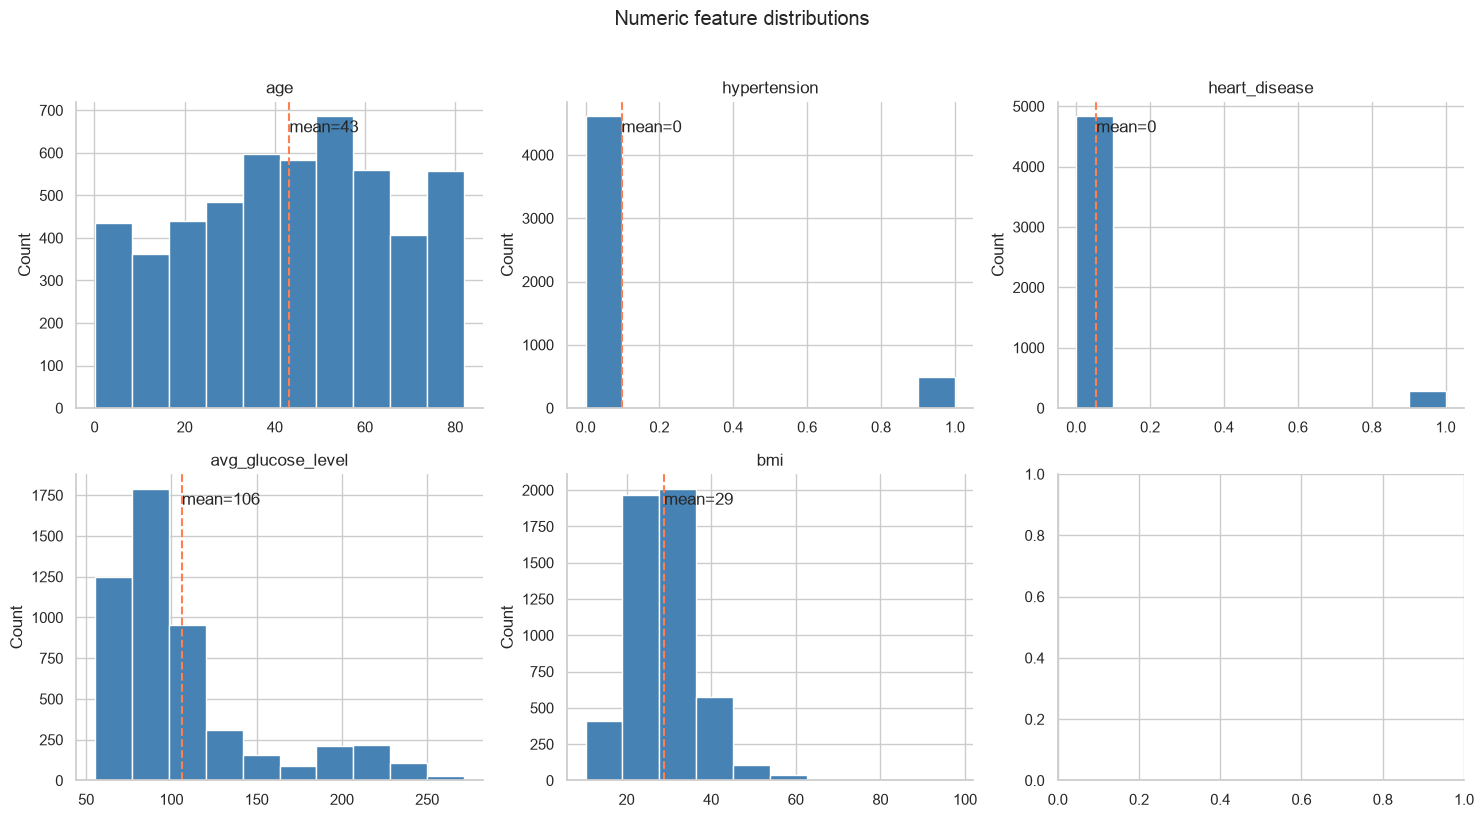

In [11]:
num_cols = ['age', 'hypertension','heart_disease','avg_glucose_level','bmi']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=10, color="steelblue", edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_ylabel("Count")
    mean_value = df[col].mean()
    axes[i].axvline(mean_value, color="coral", linestyle="--", linewidth=1.5)
    axes[i].text(mean_value, axes[i].get_ylim()[1] * 0.9, f'mean={mean_value:.0f}')

axes[5].set_visible = False

plt.suptitle('Numeric feature distributions', y=1.02)
plt.tight_layout()
plt.show()

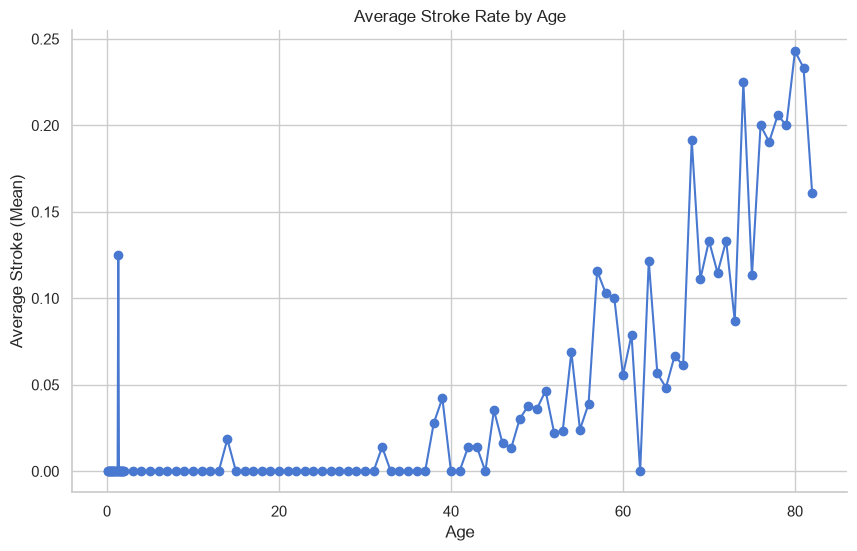

In [12]:
age_vs_stroke = df.groupby('age')['stroke'].mean()

age_vs_stroke.plot(kind='line', marker='o', figsize=(10, 6))

plt.title('Average Stroke Rate by Age')
plt.xlabel('Age')
plt.ylabel('Average Stroke (Mean)')
plt.grid(True)
plt.show()

### 3.3 Categorical feature distributions

In [13]:
df.select_dtypes(include=['str']).columns.tolist()

['gender', 'ever_married', 'work_type', 'residence_type', 'smoking_status']

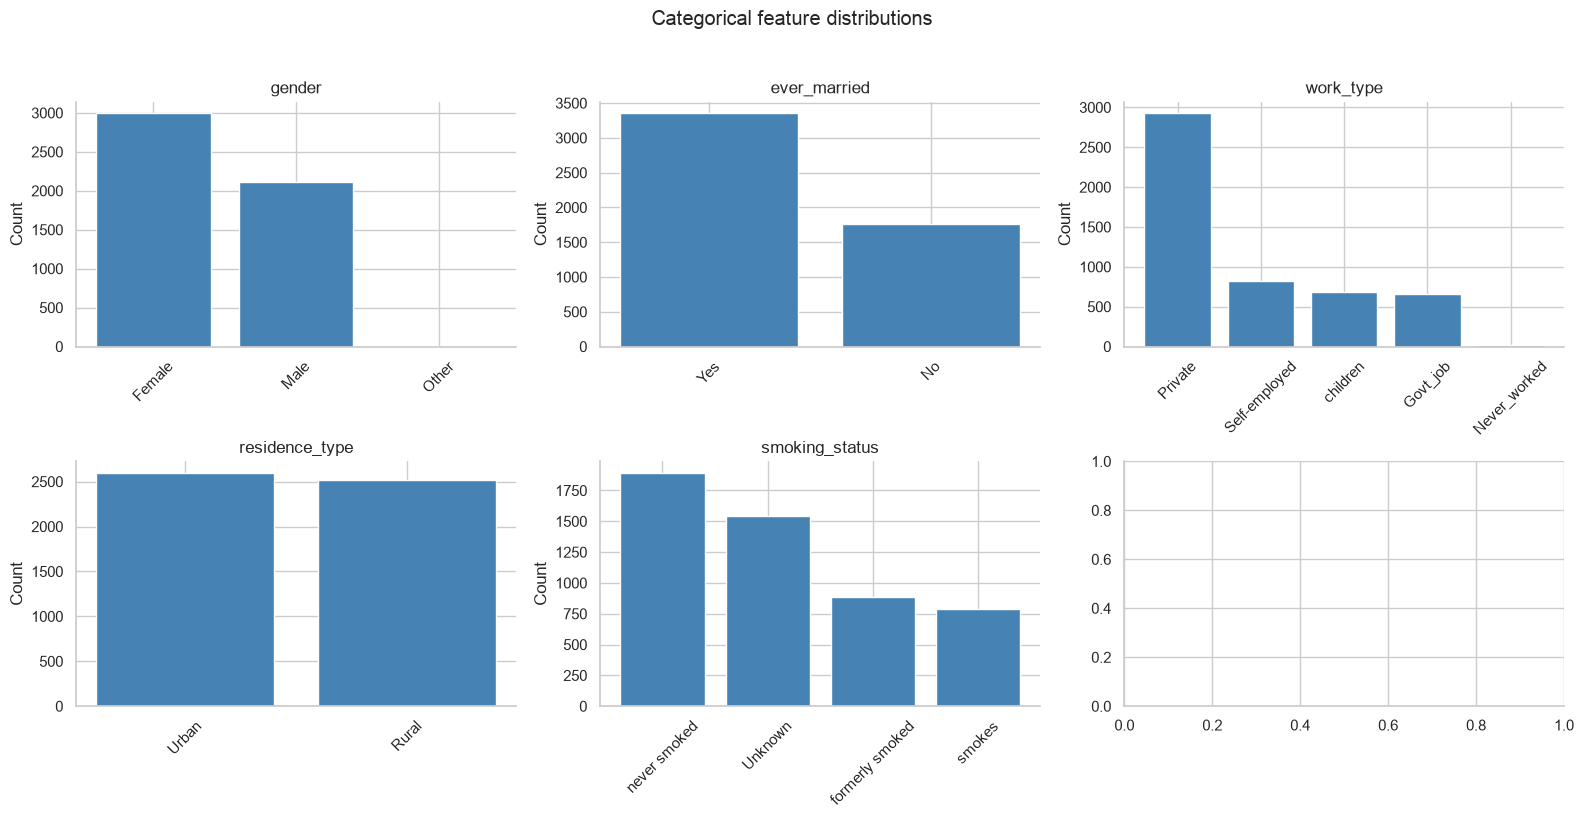

In [14]:
cat_cols = ['gender', 'ever_married', 'work_type', 'residence_type', 'smoking_status']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, color="steelblue", edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Categorical feature distributions', y=1.02)
plt.tight_layout()
plt.show()

In [15]:
df.groupby('ever_married')['age'].mean()

ever_married
No     22.014229
Yes    54.342082
Name: age, dtype: float64

Married people have more average age.

### 3.4 Descriptive statistics

In [16]:
summary = df.describe().round(1)
summary

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.0,5110.0,5110.0,5110.0,5110.0,5110.0,5110.0
mean,36517.8,43.2,0.1,0.1,106.1,28.9,0.0
std,21161.7,22.6,0.3,0.2,45.3,7.7,0.2
min,67.0,0.1,0.0,0.0,55.1,10.3,0.0
25%,17741.2,25.0,0.0,0.0,77.2,23.8,0.0
50%,36932.0,45.0,0.0,0.0,91.9,28.1,0.0
75%,54682.0,61.0,0.0,0.0,114.1,32.8,0.0
max,72940.0,82.0,1.0,1.0,271.7,97.6,1.0


**Key observations:**

- Average BMI is bigger than healthy threshold(25).

- Mean age in the dataset is 43.2.

## 4. Bivariate analysis

### 4.1 Numeric features vs stroke

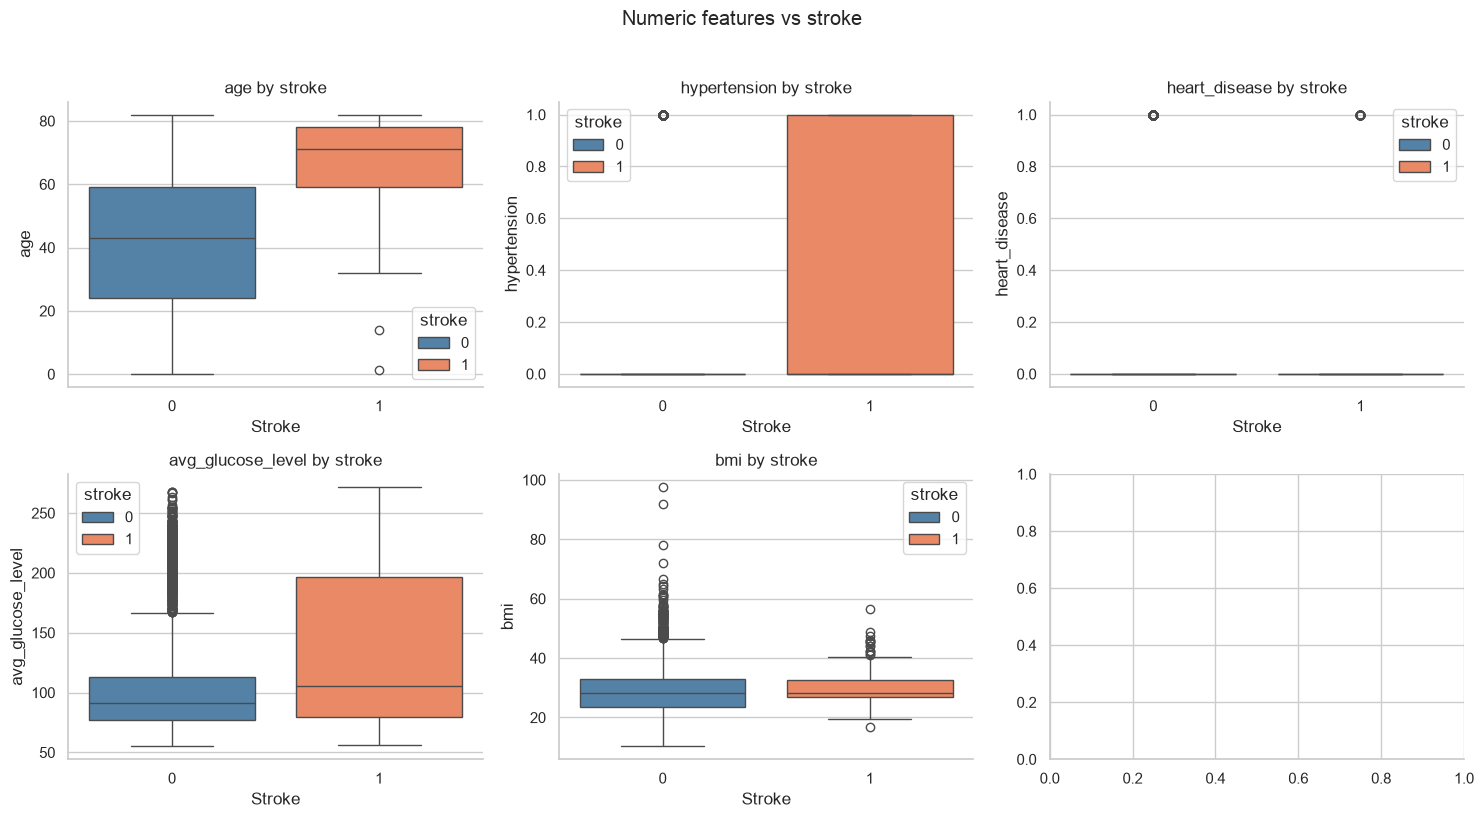

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x="stroke", y=col, ax=axes[i], palette={0: "steelblue", 1: "coral"}, hue="stroke")
    axes[i].set_title(f'{col} by stroke')
    axes[i].set_xlabel('Stroke')

axes[5].set_visible = False
plt.suptitle('Numeric features vs stroke', y=1.02)
plt.tight_layout()
plt.show()

**Key observations:**

- Age seems to be correlated with stroke.

- Hypertension is strongly associated with stroke.

- Stroke patients have higher average glucose levels.

- Although the dataset's average BMI is high, there is no meaningful difference in BMI between patient groups.

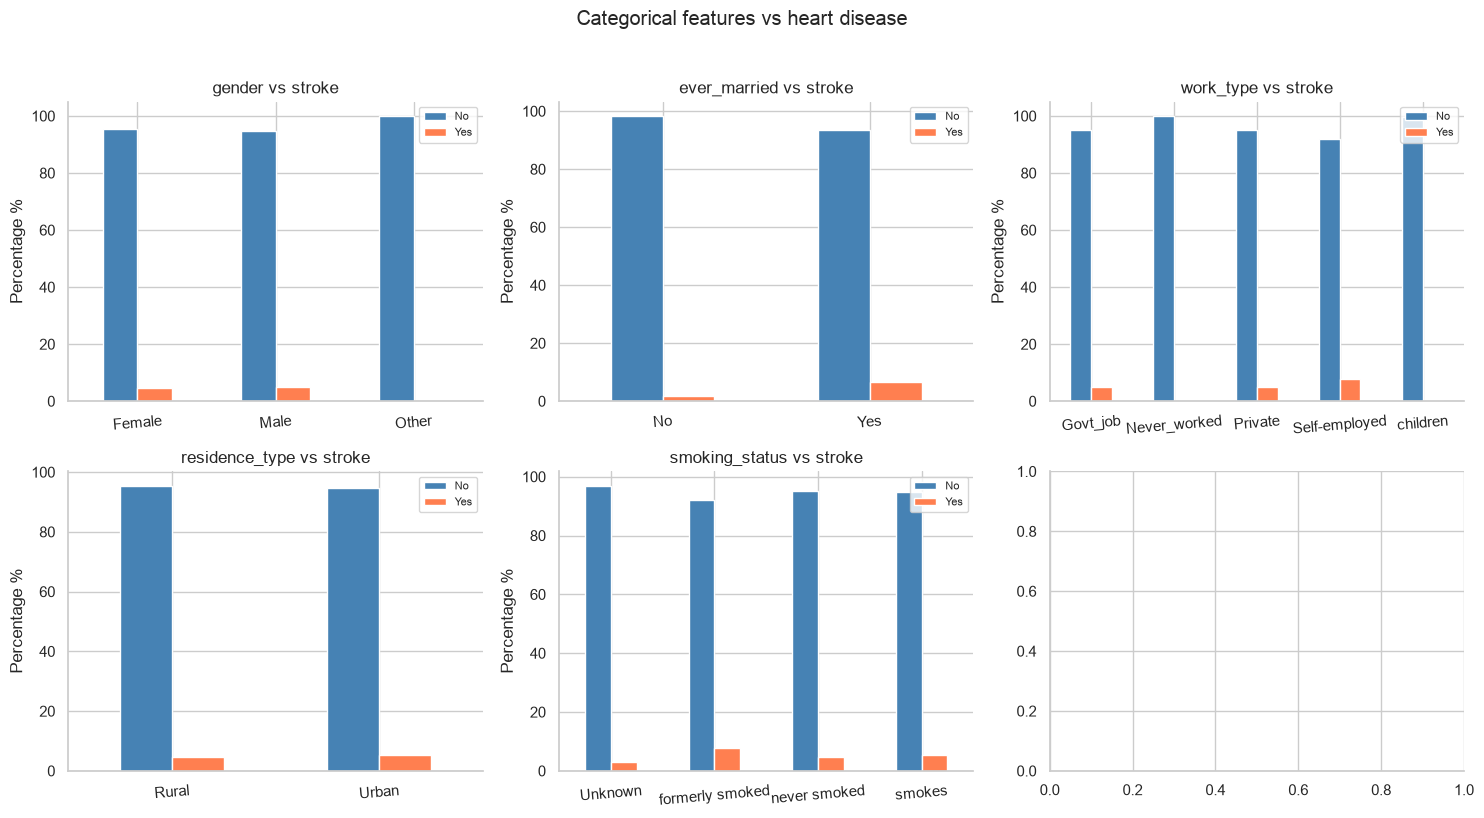

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['stroke'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['steelblue', 'coral'], edgecolor='white')
    axes[i].set_title(f'{col} vs stroke')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Percentage %')
    axes[i].tick_params(axis='x', rotation=5)
    axes[i].legend(['No', 'Yes'], fontsize=8)

plt.suptitle('Categorical features vs heart disease', y=1.02)
plt.tight_layout()
plt.show()

**Key observations:**

- Married patients have strokes. Married people may have higher age. Probably this correlaton due to age.

- Self-employed people have higher rate of stroke. Children and never worked people have no incidence of disease.

- Urban population has slightly more stroke comparing to rural.

- Smokers and former smokers have higher rate of disease.

## 5. Multivariate analysis

### 5.1 Correlation matrix

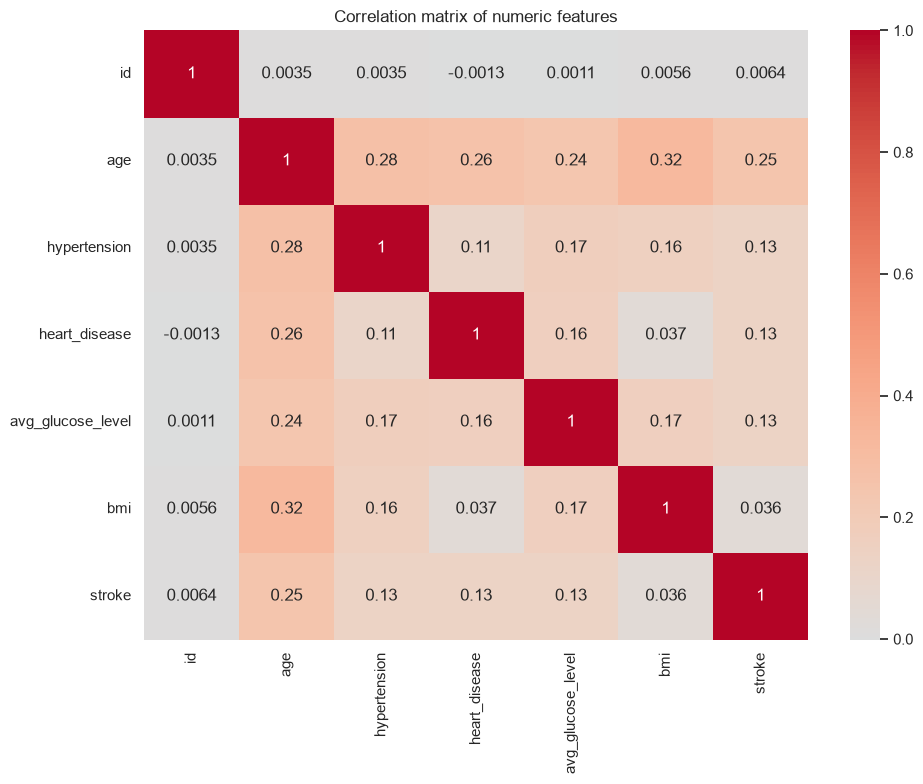

In [19]:
# Encode target for correlation
df_corr = df.copy()

# Numeric columns only
numeric_df = df_corr.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, ax=ax)

plt.title('Correlation matrix of numeric features')
plt.tight_layout()
plt.show()

### 5.2 Pairplots of top discriminating features

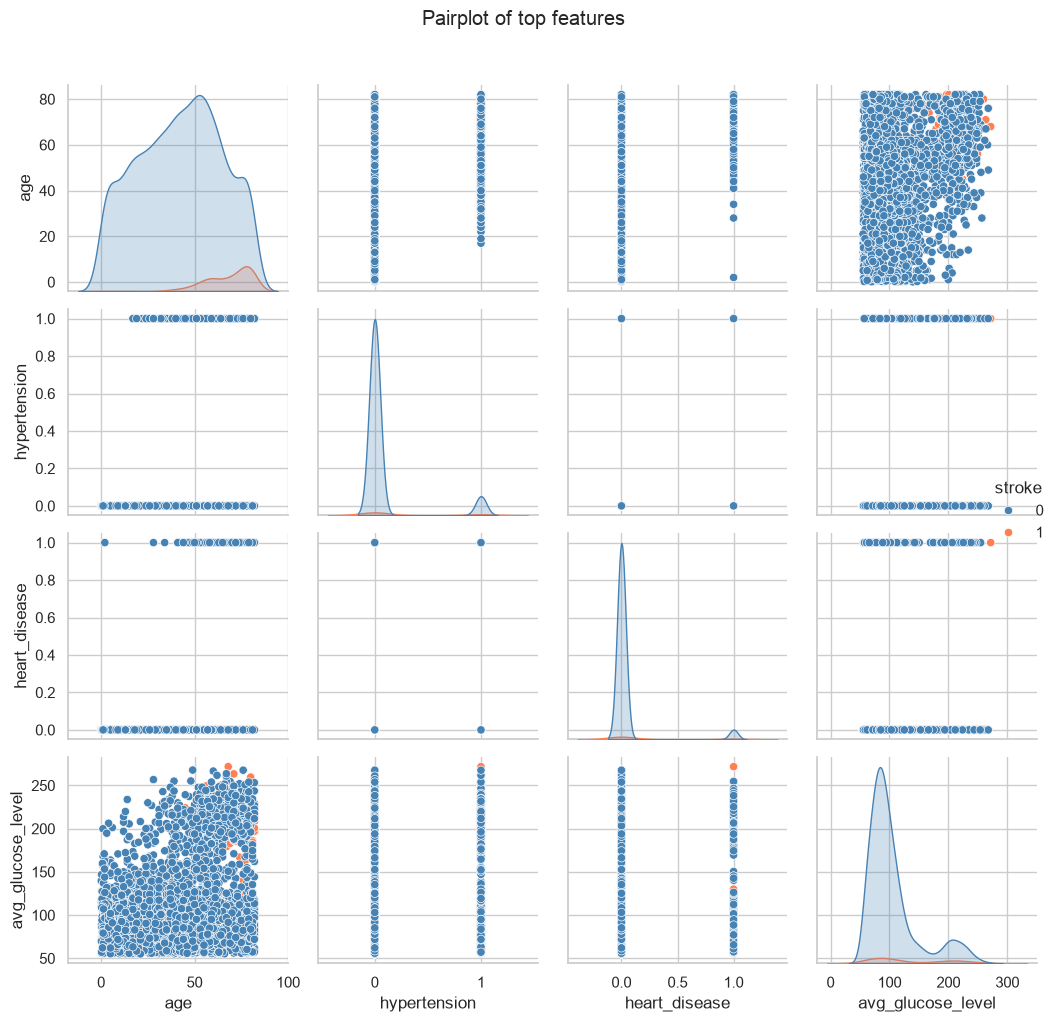

In [20]:
top_features = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level']
target = ['stroke']
pair_plot_columns = top_features + target

sns.pairplot(df[pair_plot_columns], hue='stroke', palette={0: "steelblue", 1: "coral"}, diag_kind='kde')
plt.suptitle('Pairplot of top features', y=1.02)
plt.tight_layout()
plt.show()

## 6. Clinical insights summary

Analysis of 5110 patients from the Stroke Prediction dataset reveals several clinically meaningful patterns:

1. Age, hypertension, heart disease, average glucose level are strongest numerical predictors of stroke.

2. Self-employed people have higher rate of stroke. Children and never worked people have no incidence of disease.

3. Urban population has slightly more stroke comparing to rural.

4. Smokers and former smokers have higher rate of disease.

5. BMI itself is not associated directly with stroke.

6. Dataset has moderate demographic balance of genders, urban-rural populaton.

7. Key features for modeling Based on this EDA, the most informative features for a classifier are: age, hypertension, heart disease, average glucose level, work type, smoking status.

## 7. Next steps

This EDA suggests the following modeling approach:

- Algorithm: Tree-based models (Random Forest, XGBoost) are well-suited given the mix of numeric and categorical features and likely nonlinear relationships. Use Logistic Regression as a baseline model.

- Feature engineering: hypertension and heart disease actually are not numeric variables, handle them as categorical. Standard scale numeric features(for logistic regression), one hot encode categorical ones.

- Evaluation metric: ROC-AUC preferred over accuracy given the clinical cost asymmetry - missing a true positive (undiagnosed disease) is more costly than a false positive. Also accuracy would be misleading in such an imbalanced dataset.

- Heavy class imbalance: oversampling needed, or tune model parameters to handle such data.

- Validation: Stratified k-fold cross-validation to preserve class ratios across folds.